<a href="https://colab.research.google.com/github/Kushagra3219/CNN-Models/blob/main/SparseGraph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

df = pd.read_csv('ratings.csv')
print(df.columns)

Index(['spid', 'rating', 'COMMEQTA', 'LLPLOANS', 'COSTTOINCOME', 'ROE',
       'LIQASSTA', 'SIZE'],
      dtype='object')


In [ ]:
df.head()

,spid,rating,COMMEQTA,LLPLOANS,COSTTOINCOME,ROE,LIQASSTA,SIZE
0,141126,7,0.088445,0.057333,0.582160,0.177753,0.374932,18.818966
1,342066,5,0.055974,0.009640,0.526015,-0.122580,0.497892,19.072266
2,366790,10,0.154322,0.014402,2.084550,-0.166647,0.087426,16.075995
3,146854,1,0.026977,0.002951,0.248881,0.102982,0.457657,18.101099
4,319262,2,0.096891,0.002645,0.544106,0.178183,0.148163,15.758143


In [ ]:
print("dimension of credit data: {}".format(df.shape))

dimension of credit data: (5000, 8)


In [ ]:
print(df.groupby('rating').size())

rating
1     500
2     500
3     500
4     500
5     500
6     500
7     500
8     500
9     500
10    500
dtype: int64


<Axes: xlabel='rating', ylabel='count'>

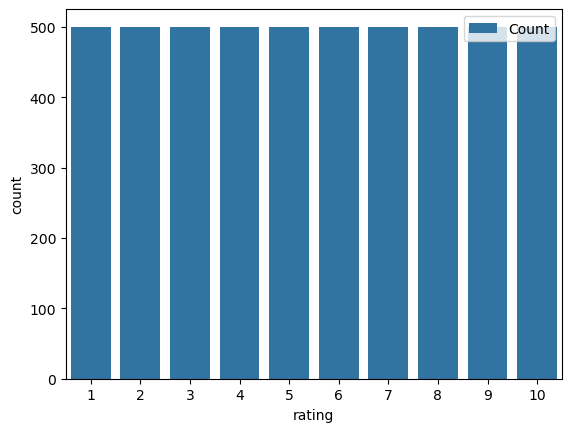

In [ ]:
import seaborn as sns
sns.countplot(x='rating', data=df, label="Count")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   spid          5000 non-null   int64  
 1   rating        5000 non-null   int64  
 2   COMMEQTA      5000 non-null   float64
 3   LLPLOANS      5000 non-null   float64
 4   COSTTOINCOME  5000 non-null   float64
 5   ROE           5000 non-null   float64
 6   LIQASSTA      5000 non-null   float64
 7   SIZE          5000 non-null   float64
dtypes: float64(6), int64(2)
memory usage: 312.6 KB


In [ ]:
df.shape

(5000, 8)

In [ ]:
df.drop(['spid'], axis=1, inplace=True)

In [ ]:
df.columns

Index(['rating', 'COMMEQTA', 'LLPLOANS', 'COSTTOINCOME', 'ROE', 'LIQASSTA',
       'SIZE'],
      dtype='object')

In [ ]:
df['rating'].value_counts()

rating
7     500
5     500
10    500
1     500
2     500
4     500
8     500
3     500
9     500
6     500
Name: count, dtype: int64

In [ ]:
df.groupby('rating').mean()

,COMMEQTA,LLPLOANS,COSTTOINCOME,ROE,LIQASSTA,SIZE
rating,,,,,,
1,0.057003,0.001871,0.494334,0.083958,0.437552,18.605855
2,0.057911,0.003646,0.592275,0.139777,0.233581,18.387910
3,0.092421,0.005555,0.458752,0.095894,0.268491,18.482072
4,0.146309,0.035710,0.570748,0.080668,0.317805,18.240401
5,0.090053,0.009089,0.690173,0.054626,0.364121,18.609178
6,0.087127,0.047742,0.869896,-0.012485,0.424102,18.456604
7,0.096847,0.030545,0.612404,0.154562,0.250780,17.594119
8,0.183537,0.015903,0.623534,0.054504,0.130751,14.580082
9,0.066718,0.021108,0.635265,0.101699,0.248671,17.337787


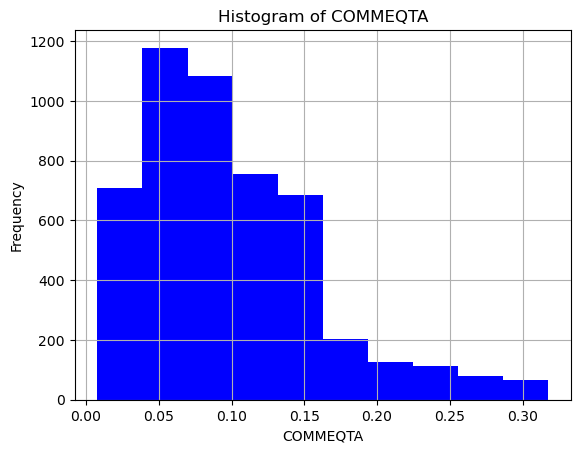

In [ ]:
%matplotlib inline
df['COMMEQTA'].hist(color="blue")
plt.title("Histogram of COMMEQTA")
plt.xlabel("COMMEQTA")
plt.ylabel("Frequency")
plt.savefig("hist_COMMEQTA")

In [ ]:
df['COMMEQTA'].describe()

count    5000.000000
mean        0.098667
std         0.060603
min         0.007804
25%         0.054212
50%         0.085571
75%         0.133225
max         0.317547
Name: COMMEQTA, dtype: float64

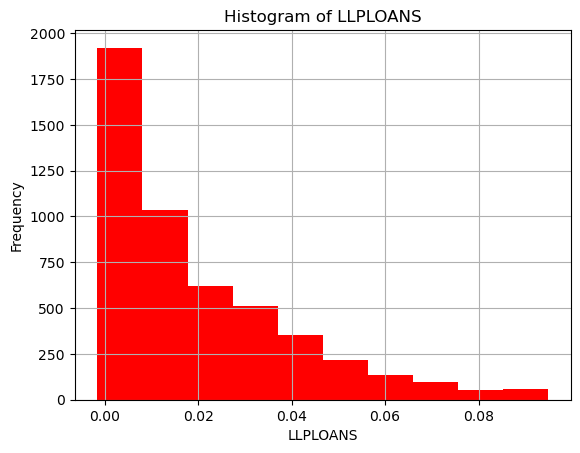

In [ ]:
%matplotlib inline
df['LLPLOANS'].hist(color="red")
plt.title("Histogram of LLPLOANS")
plt.xlabel("LLPLOANS")
plt.ylabel("Frequency")
plt.savefig("hist_LLPLOANS")

In [ ]:
df['LLPLOANS'].describe()

count    5000.000000
mean        0.019881
std         0.020050
min        -0.001574
25%         0.003987
50%         0.012582
75%         0.030034
max         0.094904
Name: LLPLOANS, dtype: float64

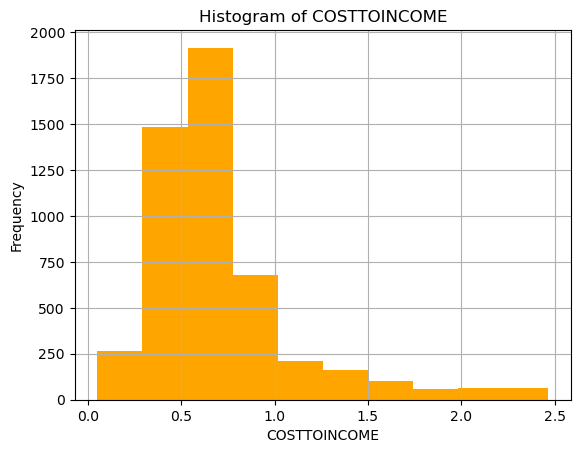

In [ ]:
%matplotlib inline
df['COSTTOINCOME'].hist(color="orange")
plt.title("Histogram of COSTTOINCOME")
plt.xlabel("COSTTOINCOME")
plt.ylabel("Frequency")
plt.savefig("hist_COSTTOINCOME")

In [ ]:
df['COSTTOINCOME'].describe()

count    5000.000000
mean        0.707218
std         0.396710
min         0.051317
25%         0.469341
50%         0.628569
75%         0.791117
max         2.465519
Name: COSTTOINCOME, dtype: float64

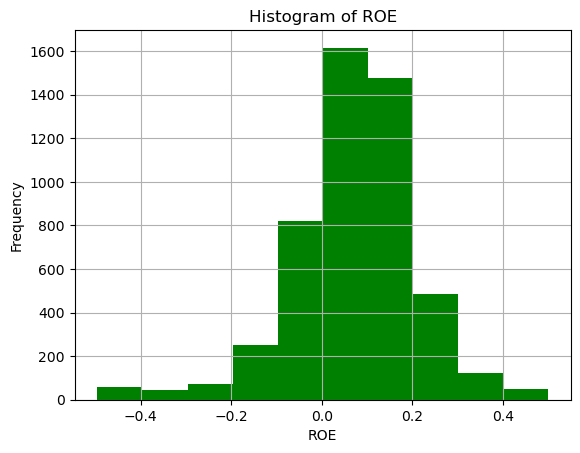

In [ ]:
%matplotlib inline
df['ROE'].hist(color="green")
plt.title("Histogram of ROE")
plt.xlabel("ROE")
plt.ylabel("Frequency")
plt.savefig("hist_ROE")

In [ ]:
df['ROE'].describe()

count    5000.000000
mean        0.072434
std         0.136688
min        -0.495290
25%         0.002513
50%         0.085189
75%         0.154354
max         0.499487
Name: ROE, dtype: float64

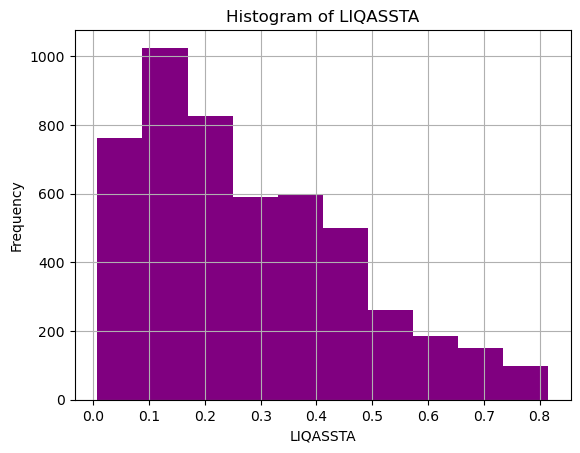

In [ ]:
%matplotlib inline
df['LIQASSTA'].hist(color="purple")
plt.title("Histogram of LIQASSTA")
plt.xlabel("LIQASSTA")
plt.ylabel("Frequency")
plt.savefig("hist_LIQASSTA")

In [ ]:
df['LIQASSTA'].describe()

count    5000.000000
mean        0.278848
std         0.185743
min         0.007040
25%         0.129720
50%         0.234405
75%         0.404874
max         0.815533
Name: LIQASSTA, dtype: float64

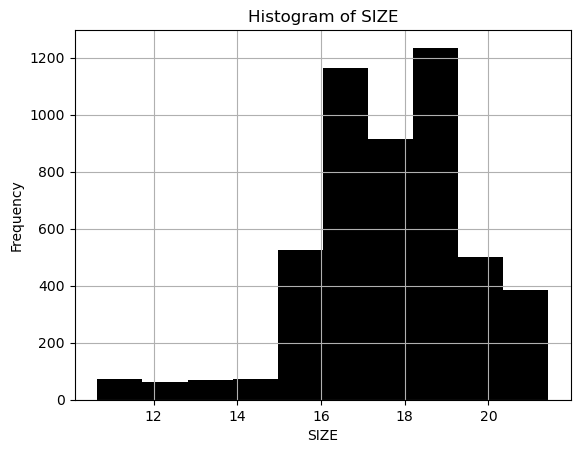

In [ ]:
%matplotlib inline
df['SIZE'].hist(color="black")
plt.title("Histogram of SIZE")
plt.xlabel("SIZE")
plt.ylabel("Frequency")
plt.savefig("hist_SIZE")

In [ ]:
df['SIZE'].describe()

count    5000.000000
mean       17.666594
std         1.901862
min        10.652532
25%        16.464669
50%        17.798592
75%        18.951919
max        21.430289
Name: SIZE, dtype: float64

In [ ]:
X = df.loc[:, df.columns != "rating"]
y = df.loc[:, df.columns == "rating"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42, stratify=y)

C:\Users\kanis\anaconda3\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Users\kanis\anaconda3\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Users\kanis\anaconda3\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Users\kanis\anaconda3\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_sam

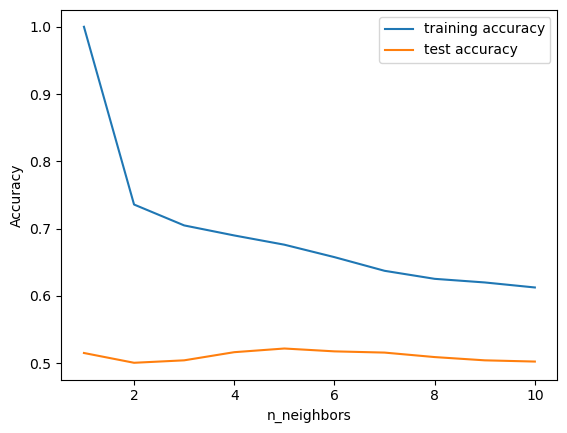

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
training_accuracy = []
test_accuracy = []
# try n_neighbors from 1 to 10
neighbors_settings = range(1, 11)
for n_neighbors in neighbors_settings:
    # build the model
    knn = KNeighborsClassifier(n_neighbors=n_neighbors)
    knn.fit(X_train, y_train)
    # record training set accuracy
    training_accuracy.append(knn.score(X_train, y_train))
    # record test set accuracy
    test_accuracy.append(knn.score(X_test, y_test))
plt.plot(neighbors_settings, training_accuracy, label="training accuracy")
plt.plot(neighbors_settings, test_accuracy, label="test accuracy")
plt.ylabel("Accuracy")
plt.xlabel("n_neighbors")
plt.legend()
plt.savefig('knn_compare_model')

In [ ]:
knn = KNeighborsClassifier(n_neighbors=4)
knn.fit(X_train, y_train)
print('Accuracy of K-NN classifier on training set: {:.2f}'.format(knn.score(X_train, y_train)))
print('Accuracy of K-NN classifier on test set: {:.2f}'.format(knn.score(X_test, y_test)))

Accuracy of K-NN classifier on training set: 0.69
Accuracy of K-NN classifier on test set: 0.52


C:\Users\kanis\anaconda3\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


In [ ]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(random_state=42).fit(X_train, y_train)
print("Training set score: {:.3f}".format(logreg.score(X_train, y_train)))
print("Test set score: {:.3f}".format(logreg.score(X_test, y_test)))

C:\Users\kanis\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Training set score: 0.485
Test set score: 0.453


C:\Users\kanis\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
logreg001 = LogisticRegression(C=0.01, random_state=42).fit(X_train, y_train)
print("Training set accuracy: {:.3f}".format(logreg001.score(X_train, y_train)))
print("Test set accuracy: {:.3f}".format(logreg001.score(X_test, y_test)))

C:\Users\kanis\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Training set accuracy: 0.337
Test set accuracy: 0.316


C:\Users\kanis\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
logreg100 = LogisticRegression(C=100, random_state=42).fit(X_train, y_train)
print("Training set accuracy: {:.3f}".format(logreg100.score(X_train, y_train)))
print("Test set accuracy: {:.3f}".format(logreg100.score(X_test, y_test)))

C:\Users\kanis\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Training set accuracy: 0.495
Test set accuracy: 0.464


C:\Users\kanis\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.tree import DecisionTreeClassifier
tree1 = DecisionTreeClassifier(random_state=42)
tree1.fit(X_train, y_train)
print("Accuracy on training set: {:.3f}".format(tree1.score(X_train, y_train)))
print("Accuracy on test set: {:.3f}".format(tree1.score(X_test, y_test)))

Accuracy on training set: 1.000
Accuracy on test set: 0.700


In [ ]:
tree2 = DecisionTreeClassifier(max_depth=14, random_state=42)
tree2.fit(X_train, y_train)
print("Accuracy on training set: {:.3f}".format(tree2.score(X_train, y_train)))
print("Accuracy on test set: {:.3f}".format(tree2.score(X_test, y_test)))

Accuracy on training set: 0.900
Accuracy on test set: 0.731


In [ ]:
df_features = [x for i,x in enumerate(X.columns) if i!= len(X.columns) ]

In [ ]:
print("Feature importances:\n{}".format(tree2.feature_importances_))

Feature importances:
[0.10678475 0.23736728 0.17098942 0.18010008 0.09578607 0.20897239]


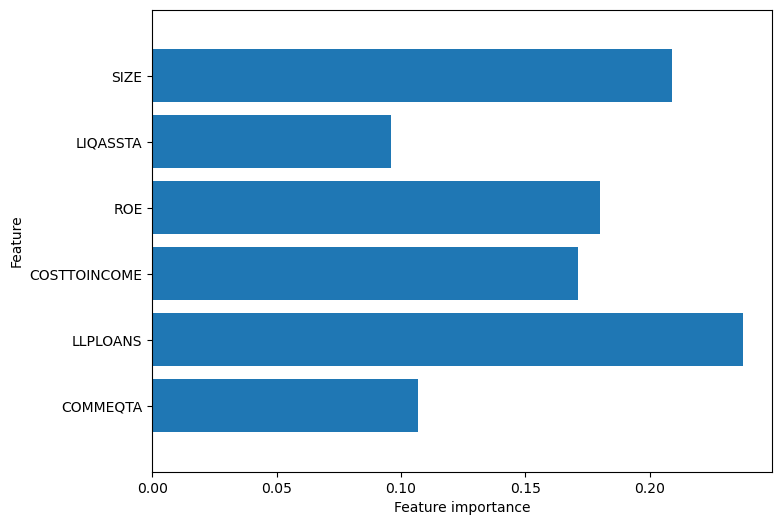

In [ ]:
def plot_feature_importances_credit(model):
    plt.figure(figsize=(8,6))
    n_features = len(X.columns)
    plt.barh(range(n_features), model.feature_importances_, align='center')
    plt.yticks(np.arange(n_features), df_features)
    plt.xlabel("Feature importance")
    plt.ylabel("Feature")
    plt.ylim(-1, n_features)

plot_feature_importances_credit(tree2)
plt.savefig('feature_importance')

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
print("Accuracy on training set: {:.3f}".format(rf.score(X_train, y_train)))
print("Accuracy on test set: {:.3f}".format(rf.score(X_test, y_test)))

C:\Users\kanis\anaconda3\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Accuracy on training set: 1.000
Accuracy on test set: 0.779


In [ ]:
rf1 = RandomForestClassifier(max_depth=12, n_estimators=100, random_state=42)
rf1.fit(X_train, y_train)
print("Accuracy on training set: {:.3f}".format(rf1.score(X_train, y_train)))
print("Accuracy on test set: {:.3f}".format(rf1.score(X_test, y_test)))

C:\Users\kanis\anaconda3\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Accuracy on training set: 0.910
Accuracy on test set: 0.790


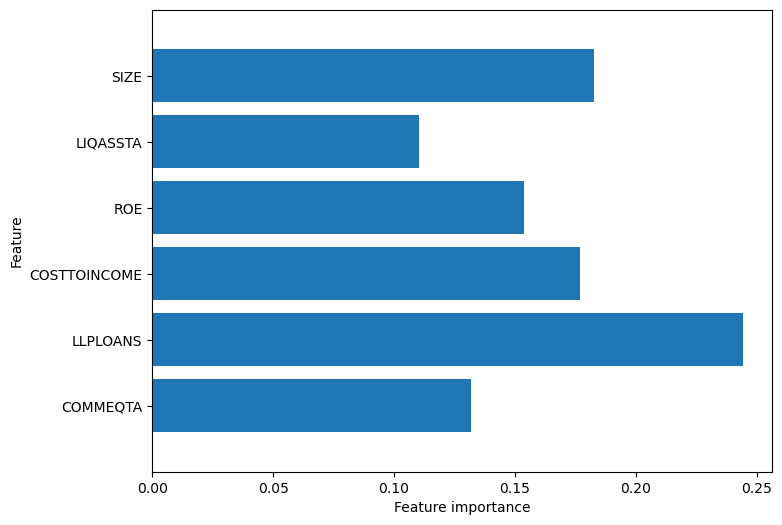

In [ ]:
plot_feature_importances_credit(rf1)

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
print("Accuracy on training set: {:.3f}".format(gb.score(X_train, y_train)))
print("Accuracy on test set: {:.3f}".format(gb.score(X_test, y_test)))

C:\Users\kanis\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Accuracy on training set: 0.920
Accuracy on test set: 0.805


In [ ]:
gb1 = GradientBoostingClassifier(max_depth=1, random_state=42)
gb1.fit(X_train, y_train)
print("Accuracy on training set: {:.3f}".format(gb1.score(X_train, y_train)))
print("Accuracy on test set: {:.3f}".format(gb1.score(X_test, y_test)))

C:\Users\kanis\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Accuracy on training set: 0.813
Accuracy on test set: 0.784


In [ ]:
gb2 = GradientBoostingClassifier(learning_rate=0.01, random_state=42)
gb2.fit(X_train, y_train)
print("Accuracy on training set: {:.3f}".format(gb2.score(X_train, y_train)))
print("Accuracy on test set: {:.3f}".format(gb2.score(X_test, y_test)))

C:\Users\kanis\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Accuracy on training set: 0.763
Accuracy on test set: 0.727


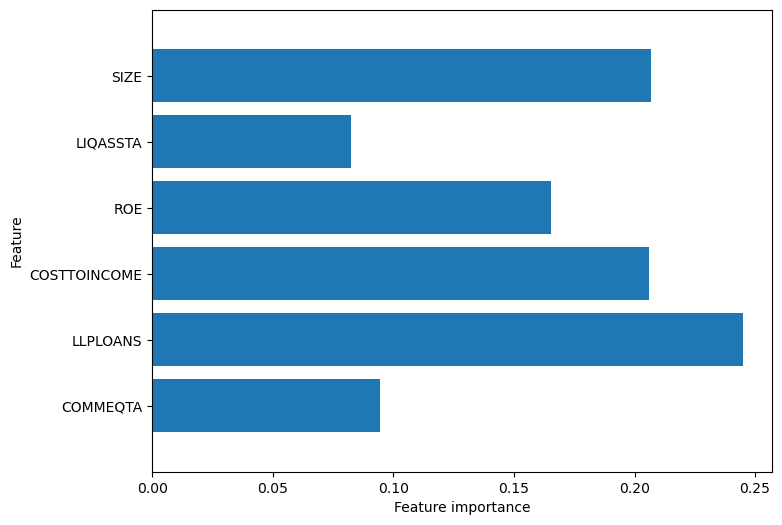

In [ ]:
plot_feature_importances_credit(gb)

In [ ]:
from sklearn.svm import SVC
svc1 = SVC(random_state=42)
svc1.fit(X_train, y_train)
print("Accuracy on training set: {:.2f}".format(svc1.score(X_train, y_train)))
print("Accuracy on test set: {:.2f}".format(svc1.score(X_test, y_test)))

C:\Users\kanis\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Accuracy on training set: 0.33
Accuracy on test set: 0.33


In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)
svc2 = SVC(random_state=42)
svc2.fit(X_train_scaled, y_train)
print("Accuracy on training set: {:.2f}".format(svc2.score(X_train_scaled, y_train)))
print("Accuracy on test set: {:.2f}".format(svc2.score(X_test_scaled, y_test)))

C:\Users\kanis\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Accuracy on training set: 0.73
Accuracy on test set: 0.68


In [ ]:
svc3 = SVC(C=100, random_state=42)
svc3.fit(X_train_scaled, y_train)
print("Accuracy on training set: {:.3f}".format(svc3.score(X_train_scaled, y_train)))
print("Accuracy on test set: {:.3f}".format(svc3.score(X_test_scaled, y_test)))

C:\Users\kanis\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Accuracy on training set: 0.822
Accuracy on test set: 0.730


In [ ]:
from sklearn.neural_network import MLPClassifier
mlp1 = MLPClassifier(random_state=42)
mlp1.fit(X_train, y_train)
print("Accuracy on training set: {:.2f}".format(mlp1.score(X_train, y_train)))
print("Accuracy on test set: {:.2f}".format(mlp1.score(X_test, y_test)))

C:\Users\kanis\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:1219: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Accuracy on training set: 0.57
Accuracy on test set: 0.56


C:\Users\kanis\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)
mlp2 = MLPClassifier(random_state=42)
mlp2.fit(X_train_scaled, y_train)
print("Accuracy on training set: {:.3f}".format(mlp2.score(X_train_scaled, y_train)))
print("Accuracy on test set: {:.3f}".format(mlp2.score(X_test_scaled, y_test)))

C:\Users\kanis\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:1219: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Accuracy on training set: 0.784
Accuracy on test set: 0.730


C:\Users\kanis\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
mlp3 = MLPClassifier(max_iter=1000, random_state=42)
mlp3.fit(X_train_scaled, y_train)
print("Accuracy on training set: {:.3f}".format(mlp3.score(X_train_scaled, y_train)))
print("Accuracy on test set: {:.3f}".format(mlp3.score(X_test_scaled, y_test)))

C:\Users\kanis\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:1219: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Accuracy on training set: 0.839
Accuracy on test set: 0.740


In [ ]:
mlp4 = MLPClassifier(max_iter=1000, alpha=1, random_state=42)
mlp4.fit(X_train_scaled, y_train)
print("Accuracy on training set: {:.3f}".format(mlp4.score(X_train_scaled, y_train)))
print("Accuracy on test set: {:.3f}".format(mlp4.score(X_test_scaled, y_test)))

C:\Users\kanis\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:1219: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Accuracy on training set: 0.734
Accuracy on test set: 0.687


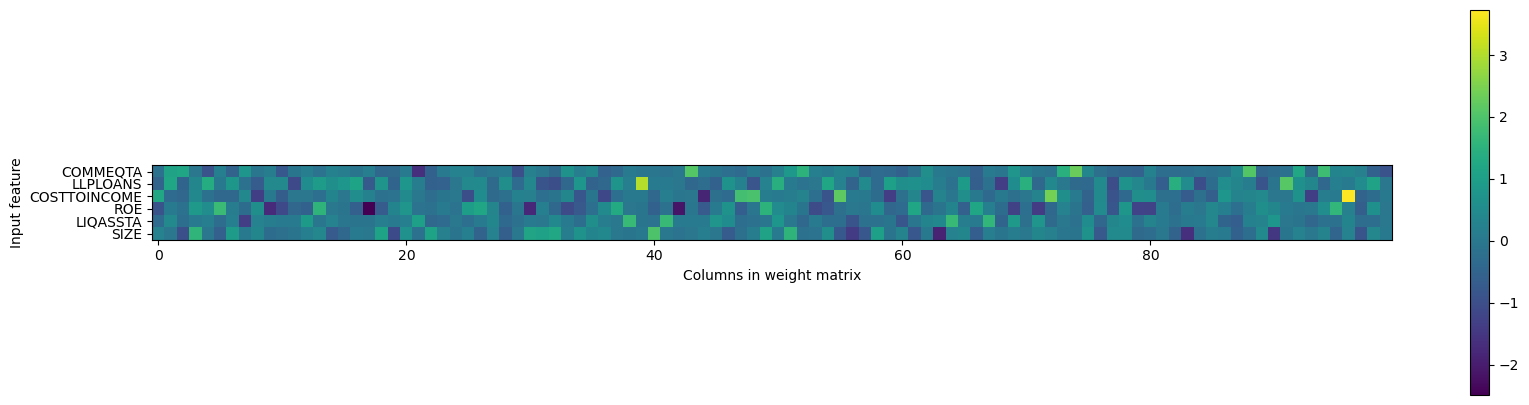

In [ ]:
plt.figure(figsize=(20, 5))
plt.imshow(mlp3.coefs_[0], interpolation="none", cmap='viridis')
plt.yticks(range(len(X.columns)), df_features)
plt.xlabel("Columns in weight matrix")
plt.ylabel("Input feature")
plt.colorbar()

In [ ]:
algorithms = ["k-Nearest Neighbors", "Logistic Regression", "Decision Trees", "Random Forest",
              "Gradient Boosting", "Support Vector Machine", "Deep Learning"]

tests_accuracy = [knn.score(X_test, y_test), logreg100.score(X_test, y_test), tree2.score(X_test, y_test),
 rf1.score(X_test, y_test), gb.score(X_test, y_test), svc3.score(X_test_scaled, y_test),
 mlp3.score(X_test_scaled, y_test)]

compare_algorithms = pd.DataFrame({ "Algorithms": algorithms, "Tests Accuracy": tests_accuracy })
compare_algorithms.sort_values(by = "Tests Accuracy", ascending = False)

,Algorithms,Tests Accuracy
4,Gradient Boosting,0.805455
3,Random Forest,0.790303
6,Deep Learning,0.740000
2,Decision Trees,0.730909
0,k-Nearest Neighbors,0.516364
1,Logistic Regression,0.463636
5,Support Vector Machine,0.100000


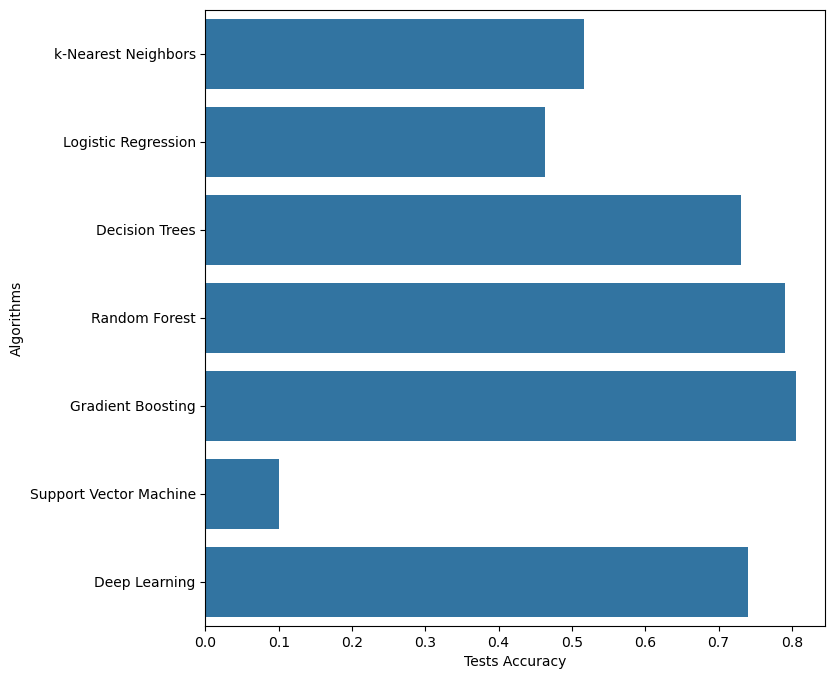

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.figure(figsize=(8,8))
sns.barplot(x = "Tests Accuracy", y = "Algorithms", data = compare_algorithms)
plt.show()

In [ ]:
model = gb
model

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [ ]:
predictions = model.predict(X_test)

In [ ]:
for i in predictions:
    print(i)

3
8
10
10
9
2
3
2
2
1
4
7
10
5
1
4
2
2
7
7
7
3
9
6
9
2
8
9
3
1
9
6
9
9
2
6
3
2
9
6
10
2
10
6
2
3
5
8
6
5
8
10
3
1
4
8
5
2
3
10
9
9
2
3
6
3
1
7
9
5
5
2
3
7
2
9
5
8
8
6
7
10
9
3
5
9
1
10
2
1
1
7
10
10
1
10
9
1
4
6
3
9
10
8
6
6
7
2
6
4
7
7
3
8
5
2
8
7
6
8
1
1
10
8
9
10
8
9
9
2
7
10
7
10
8
2
2
6
9
3
8
8
6
2
2
10
4
2
10
3
6
2
1
6
2
9
5
5
1
7
5
6
1
5
10
7
8
2
2
2
7
7
9
3
10
8
4
5
8
1
6
9
3
9
2
3
7
10
9
2
5
1
7
6
6
1
3
10
3
10
2
7
1
3
10
8
8
3
8
3
2
8
6
10
6
5
9
6
8
4
6
10
1
5
5
10
6
3
5
3
2
10
1
10
9
6
3
10
7
7
9
2
1
2
1
4
7
1
3
3
7
5
7
10
1
8
6
1
7
4
2
2
2
5
10
6
5
2
3
5
5
9
7
9
9
6
4
4
2
9
7
10
3
9
8
8
10
9
1
9
9
2
3
8
2
9
7
8
5
7
9
9
3
6
5
8
1
9
5
1
9
9
3
2
2
1
2
6
1
3
2
4
1
7
3
8
1
3
9
9
7
9
8
3
3
6
4
9
7
6
5
9
2
5
1
10
5
5
9
1
3
3
3
3
7
8
6
8
6
4
10
3
5
5
1
2
9
1
2
7
4
5
6
8
3
8
3
1
5
3
9
5
8
2
2
7
10
6
9
10
1
8
4
8
9
5
8
2
1
6
3
4
2
10
3
1
5
2
5
1
8
1
2
9
5
8
8
4
6
3
2
3
5
3
2
8
3
3
1
1
4
7
3
4
3
5
6
3
3
4
2
3
1
1
8
3
1
1
9
6
9
7
2
1
3
5
9
3
8
3
8
8
1
3
9
3
8
8
4
8
7
6
9
9
9
10
3
8
4
8

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true=y_test, y_pred=predictions)

In [ ]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
            horizontalalignment="center",
            color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

Confusion matrix, without normalization
[[159   3   0   0   3   0   0   0   0   0]
 [  5 157   3   0   0   0   0   0   0   0]
 [  0   9 140   0   4   0   1   1  10   0]
 [  1   2  12 107   4   0  17   5  15   2]
 [  3   5  32   0 115   0   4   1   3   2]
 [  0   0   1   6   8 139   5   0   5   1]
 [  0   3  10   6   2   0  95   6  41   2]
 [  0   1   4   3   1   0   1 144   9   2]
 [  2   9  17   2   8   0   3   2 118   4]
 [  0   0   0   1   1   1   1   0   6 155]]


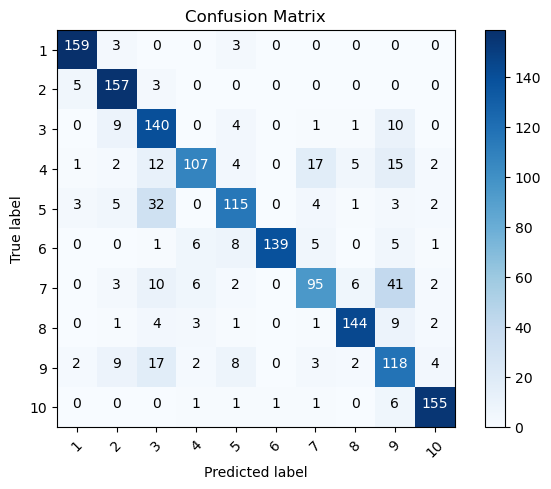

In [ ]:
import itertools
cm_plot_labels = ['1','2','3','4','5','6','7','8','9','10']
plot_confusion_matrix(cm=cm, classes=cm_plot_labels, title='Confusion Matrix')

In [ ]:

print("\033[1m The result is telling us that we have: ",(cm[0,0] + cm[1,1] + cm[2,2] + cm[3,3] + cm[4,4] +
                                                         cm[5,5] + cm[6,6] + cm[7,7] + cm[8,8] + cm[9,9] ),"correct predictions.")
print("\033[1m The result is telling us that we have: ", ( cm.sum() - (cm[0,0] + cm[1,1] + cm[2,2] +
                                                          cm[3,3] + cm[4,4] + cm[5,5] + cm[6,6] + cm[7,7] +
                                                          cm[8,8] + cm[9,9] )),"incorrect predictions.")
print("\033[1m We have a total predictions of: ",( cm.sum()) )

 The result is telling us that we have:  1329 correct predictions.
 The result is telling us that we have:  321 incorrect predictions.
 We have a total predictions of:  1650


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           1       0.94      0.96      0.95       165
           2       0.83      0.95      0.89       165
           3       0.64      0.85      0.73       165
           4       0.86      0.65      0.74       165
           5       0.79      0.70      0.74       165
           6       0.99      0.84      0.91       165
           7       0.75      0.58      0.65       165
           8       0.91      0.87      0.89       165
           9       0.57      0.72      0.63       165
          10       0.92      0.94      0.93       165

    accuracy                           0.81      1650
   macro avg       0.82      0.81      0.81      1650
weighted avg       0.82      0.81      0.81      1650

